In [2]:
import torch
from dataset import CFMFeatureDatasetFromDir
from model import UNetModelWithFiLM
import random
import numpy as np
from t2i_feature import euler_method
import os
DATASET_PATH = "/root/mems_dataset_feature_64"
FEATURE_DIM = 17
SEED = 42
EULER_STEPS = 10
SAMPLE_FEATURE_INDICES = [0,100, 500, 800]
# SAMPLE_FEATURE_INDICES = list(range(100))

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ds = CFMFeatureDatasetFromDir(DATASET_PATH, img_size=64)
model = UNetModelWithFiLM(
    dim=(3, 64, 64), num_channels=64, num_res_blocks=1,
    feature_dim=FEATURE_DIM, mlp_hidden=128, dropout=0.05, num_heads=4
).to(device)
ckpt = torch.load("/root/Text-Guided-Image-Generation-CFM/checkpoints/epoch_0420.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

indices = [i for i in SAMPLE_FEATURE_INDICES if i < len(train_ds)]
if indices:
    feats = train_ds.features[indices]
    # print("indices:", indices)
    # print("feats:", feats)
    # import pdb; pdb.set_trace()
    feats_t = torch.from_numpy(feats).float()
    n_feats = feats_t.shape[0]
    n_total = n_feats * 1
    features_batch = feats_t.to(device)
    features_repeat = features_batch.repeat_interleave(1, dim=0)  # [n_total, feat_dim]

    noise = torch.randn((n_total, 3, 64, 64), device=device)
    t_steps = torch.linspace(0, 1, EULER_STEPS, device=device)
    dt = t_steps[1] - t_steps[0]

    model.eval()
    with torch.no_grad():
        results = euler_method(model, features_repeat, t_steps, dt, noise)
    results = results.cpu().numpy()
    
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# 取最后一帧（生成结果）
final_images = torch.from_numpy(results[-1])
grid = vutils.make_grid(final_images, nrow=4, normalize=True, value_range=(0, 1))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

ImportError: cannot import name 'UNetModelWithFiLM' from 'model' (/root/Text-Guided-Image-Generation-CFM/model/__init__.py)

200


/tmp/ipykernel_3244/1109831459.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/root/Text-Guided-Image-Generation-CFM/checkpoints/epoch_0840.pt", map

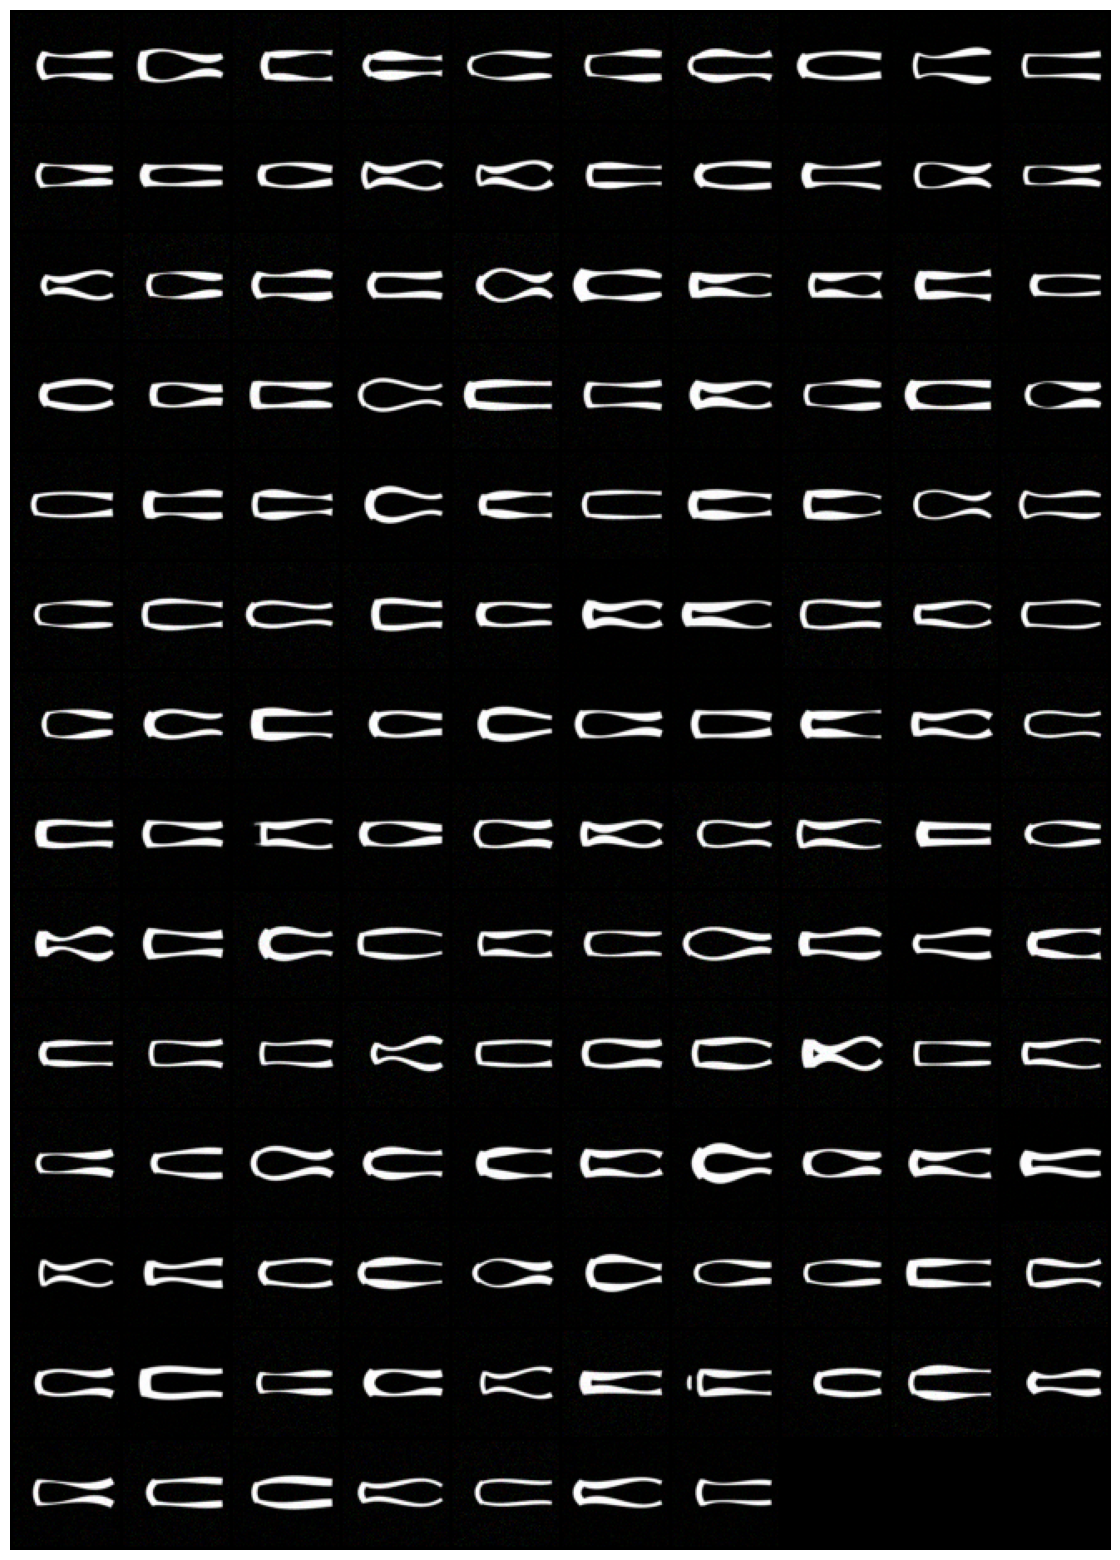

已保存 137 张图片到: ./generated_137


In [ ]:
import torch
from dataset import CFMFeatureDatasetFromDir
from model.model import UNetModelWithFiLM
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils

from scripts.t2i_feature import euler_method
import os
DATASET_PATH = "/root/dataset_2/features_64"
FEATURE_DIM = 17
SEED = 42
EULER_STEPS = 10
# SAMPLE_FEATURE_INDICES = [0, 100, 500, 800]
# # SAMPLE_FEATURE_INDICES = list(range(200))

# # 200to400
SAMPLE_FEATURE_INDICES = [i for i in range(200)]
print(len(SAMPLE_FEATURE_INDICES))

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ds = CFMFeatureDatasetFromDir(DATASET_PATH, img_size=64)
model = UNetModelWithFiLM(
    dim=(3, 64, 64), num_channels=64, num_res_blocks=1,
    feature_dim=FEATURE_DIM, mlp_hidden=128, dropout=0.05, num_heads=4
).to(device)
ckpt = torch.load("/root/checkpoints/epoch_0840.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

indices = [i for i in SAMPLE_FEATURE_INDICES if i < len(train_ds)]
if indices:
    feats = train_ds.features[indices]
    # print("indices:", indices)
    # print("feats:", feats)
    # import pdb; pdb.set_trace()
    feats_t = torch.from_numpy(feats).float()
    n_feats = feats_t.shape[0]
    n_total = n_feats * 1
    features_batch = feats_t.to(device)
    features_repeat = features_batch.repeat_interleave(1, dim=0)  # [n_total, feat_dim]

    noise = torch.randn((n_total, 3, 64, 64), device=device)
    t_steps = torch.linspace(0, 1, EULER_STEPS, device=device)
    dt = t_steps[1] - t_steps[0]

    model.eval()
    with torch.no_grad():
        results = euler_method(model, features_batch, t_steps, dt, noise)

    final_images = results[-1].detach().cpu()

    # 保存大图
    grid = vutils.make_grid(
        final_images,
        nrow=10,
        normalize=True,
        value_range=(0, 1)
    )

    plt.figure(figsize=(20, 20))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.savefig("grid_137.png", bbox_inches="tight", pad_inches=0)
    plt.show()

    # 保存单张图
    save_dir = "./generated_200"
    os.makedirs(save_dir, exist_ok=True)

    for idx, img in zip(indices, final_images):
        save_path = os.path.join(save_dir, f"idx_{idx:03d}.png")
        vutils.save_image(img, save_path, normalize=True, value_range=(0, 1))

    print(f"已保存 {len(final_images)} 张图片到: {save_dir}")

In [33]:
import torch

action = torch.rand(32, 10, 7)
# t = torch.uniform(0, 1, (32, 1))
t = torch.rand(32,1,1)
noise = torch.randn_like(action)
xt = noise * (1-t) + action * t







In [60]:
STEPS = 10
noise = torch.randn(1, 10, 7)
v = torch.rand(1, 10, 7)
t = torch.linspace(0, 1, steps=STEPS)
dt = t[1] - t[0]
t_steps = t[1:]
t_steps


tensor([0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889, 1.0000])